- Esse notebook conterá a aplicação do algoritmo UMAP. Ele lida incrivelmente bem com datasets pequenos e tenta preservar a "vizinhança global" (o que o PCA faz) junto com a "vizinhança local" (o que o t-SNE tenta fazer).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler

# carregamento e padronização

df_season = pd.read_parquet("dados_reducao.parquet")

features = ['PF', 'PA', 'Off_Pass_Yds', 'Off_Rush_Yds', 'Off_Carries', 
            'Off_Turnovers', 'Def_Sacks_Produced', 'Def_Turnovers_Forced']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_season[features])

# aplicação do UMAP

# n_neighbors: controla o balanço entre visão local (valores baixos) e global (valores altos)
# min_dist: o quão "apertado" o UMAP tem permissão para empacotar os pontos.
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, metric='euclidean')
X_umap = reducer.fit_transform(X_scaled)

df_season['UMAP1'] = X_umap[:, 0]
df_season['UMAP2'] = X_umap[:, 1]

/home/jean/NFL/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


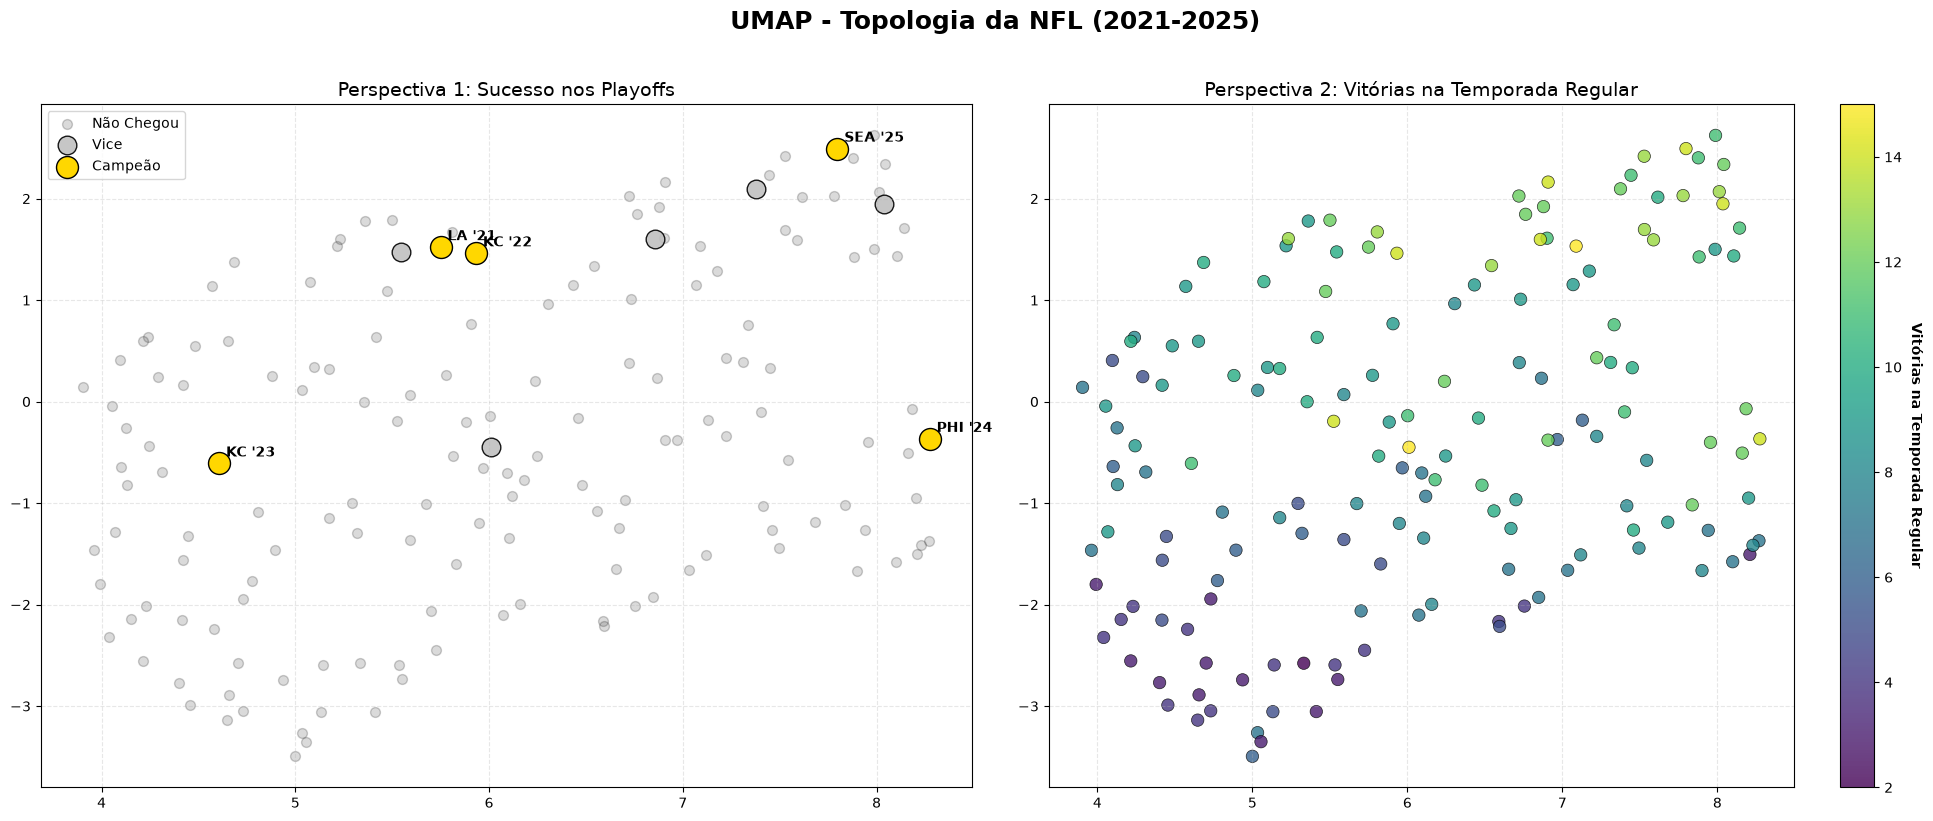

In [2]:
# visualização dupla

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.suptitle('UMAP - Topologia da NFL (2021-2025)', fontsize=18, fontweight='bold', y=1.02)

# --- Gráfico 1: Status Super Bowl ---
cores = {'Campeão': '#FFD700', 'Vice': '#C0C0C0', 'Não Chegou': '#4a4a4a', '-': '#4a4a4a'}
tamanhos = {'Campeão': 250, 'Vice': 180, 'Não Chegou': 50, '-': 50}
alphas = {'Campeão': 1.0, 'Vice': 0.9, 'Não Chegou': 0.2, '-': 0.2}

for status in ['-', 'Não Chegou', 'Vice', 'Campeão']:
    subset = df_season[df_season['Status_SB'] == status]
    if not subset.empty:
        ax1.scatter(subset['UMAP1'], subset['UMAP2'], c=cores[status], s=tamanhos[status], 
                    alpha=alphas[status], label=status, edgecolors='black', linewidth=1)

campeoes = df_season[df_season['Status_SB'] == 'Campeão']
for idx, row in campeoes.iterrows():
    ax1.annotate(f"{row['team']} '{str(row['season'])[-2:]}", (row['UMAP1'], row['UMAP2']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax1.set_title('Perspectiva 1: Sucesso nos Playoffs', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 2: Vitórias na Temporada ---
scatter_wins = ax2.scatter(df_season['UMAP1'], df_season['UMAP2'], 
                           c=df_season['Reg_Season_Wins'], cmap='viridis', 
                           s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter_wins, ax=ax2)
cbar.set_label('Vitórias na Temporada Regular', rotation=270, labelpad=15, fontweight='bold')

ax2.set_title('Perspectiva 2: Vitórias na Temporada Regular', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Sob a perspectiva 2, observa-se que o UMAP varreu, e concentrou, os times roxos e azuis-escuros para a mesma região/direção topológica, o canto inferior esquerdo. 

- Na direção/região oposta, há a concentração de pontos amarelos e verde-claros. Existe um fluxo visível do fundo à esquerda para o topo à direita. Conforme um time ajusta suas métricas em direção ao futebol americano complementar, ele segue essa direção estatística.

- Nota-se como a região intermediária que forma a ponte entre os dois extremos não está distribuída de maneira concentrada. Ela forma "ramos" distintos ao longo do caminho, algo que pode ser observado comparando os algoritmos, em que o PCA estava bem concetrado, aí o t-SNE abriu mais, e o UMAP abriu mais ainda. O algoritmo percebeu que existem várias formas de ser mediano ou medíocre (ex: um ataque aéreo irresponsável ou uma defesa exausta), mas o caminho para virar elite e chegar ao topo direito é um pouco mais estreito.

- Sob a perspectiva 1, o algoritmo sonseguiu colocar os campeões em um "cinturão" horizontal mais claro na parte superior do gráfico, indicando a semelhança estatística entre eles. Além disso, assim como no t-SNE, o Eagles de 24, e o Chiefs de 23, se mantiveram destacados dessa horizontal principal superior, confirmando que estão um pouco fora do padrão de times participantes do superbowl.

- Corroborando o que foi analisado no Iso Forest, nesse gráfico o Seattle Seahawks de 2025 está reinando quase que no máximo canto superior direito possível. Eles estão rodeados por dois times que foram Vices. Indicando que a característica deles de ter tanto ataque quanto defesa de elite, realmente deve ser o estilo de jogo ideal/perfeito.